# Project - sim SPRINT code (to be expanded on in future sprints)

This follows the pipeline described in the project README.

**Input:** [MoltBook Observatory](https://huggingface.co/datasets/SimulaMet/moltbook-observatory-archive).

**Output:** Personae, as a set of .txt containing the most representative posts for each cluster.

**Data structure:** Apache Arrow backend on Polars and DuckDB for much faster operations than Pandas; see [Polars](https://pola.rs/).

## Setup

### Libraries

Go to project root, then run ```uv init && uv sync``` to get these installed. 

Use uv, not conda or pip.

**ADD YOUR UV ENV NAME TO .GITIGNORE.**

In [23]:
from dotenv import load_dotenv
from concurrent.futures import ProcessPoolExecutor
from langdetect import detect, LangDetectException
from matplotlib.patches import Patch
from sentence_transformers import SentenceTransformer
from datasets import load_dataset
import torch
from cuml.metrics.cluster import silhouette_score
import pyarrow as pa
import pyarrow.ipc as pa_ipc
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import duckdb
import pathlib
import datetime
import uuid
import os

### Environment variables:

Duplicate ```TEMPLATE_ENV_NOSECRETS```, rename it to ```.env```, then add your secrets.

In [24]:
print("Success?")
load_dotenv()

Success?


True

### GPU management:

In [25]:
device = 'cuda:0,1' # Options: 'cpu', 'cuda:0', 'cuda:1', or 'cuda:0,1'.
# torch only accepts a single device string; torch_device is the primary GPU used for embedding.
# CUDA_VISIBLE_DEVICES exposes all selected GPUs to cuml and dask-cuda.
if "cuda" in device:
    _gpu_str = device.replace("cuda:", "")
    os.environ["CUDA_VISIBLE_DEVICES"] = _gpu_str
    torch_device = "cuda:" + _gpu_str.split(",")[0]
else:
    torch_device = "cpu"

print("Using GPU?", torch.cuda.is_available())
print(f"torch_device: {torch_device}  |  CUDA_VISIBLE_DEVICES: {os.environ.get('CUDA_VISIBLE_DEVICES', 'unset')}")

Using GPU? True
torch_device: cuda:0  |  CUDA_VISIBLE_DEVICES: 0,1


In [26]:
gpu_ids = [int(x) for x in os.environ.get("CUDA_VISIBLE_DEVICES", "").split(",") if x.strip().isdigit()]
MULTI_GPU = len(gpu_ids) > 1

# MULTI_GPU gates SentenceTransformer encoding only.
# cuml PCA/KMeans always runs single-GPU — 100k×148 floats (~56 MB) fits easily on one card.
if MULTI_GPU:
    print(f"Multi-GPU: {len(gpu_ids)} GPUs {gpu_ids}. Both used for embedding; GPU 0 used for cuml.")
else:
    print(f"Single-GPU: GPU {gpu_ids[0] if gpu_ids else 'cpu'}.")

Multi-GPU: 2 GPUs [0, 1]. Both used for embedding; GPU 0 used for cuml.


## Load dataset -> Generate embeddingz


### Load data:

Comes from the [MoltBook Observatory dataset](https://huggingface.co/datasets/SimulaMet/moltbook-observatory-archive).

In [27]:
# Download to a cache on datapool
# target_dir = 

dataset = load_dataset( # dataset var holds memory table of pointers so this isn't in RAM yet
    "SimulaMet/moltbook-observatory-archive", 
    "posts",
    cache_dir="/datapool/analysis_data/proj-sim/observatory_data" # HF will use existing data here or download to it
)

In [28]:
start_date = "2026-01-28"
end_date   = "2026-02-15"

# Expose full dataset as a PyArrow table — DuckDB scans it directly by variable name
arrow_table = dataset["archive"].data.table

posts = duckdb.sql(f"""
    SELECT *,
        TRIM(COALESCE(title, '') || ' ' || COALESCE(content, '')) AS text
    FROM arrow_table
    WHERE CAST(created_at AS DATE) BETWEEN DATE '{start_date}' AND DATE '{end_date}'
""").pl()

print(f"Loaded rows between {start_date} and {end_date}. Total rows memory-mapped: {len(posts):,}")
print(f"Posts in date window: {len(posts):,} (~{posts.estimated_size('mb'):.1f} MB in RAM)")

texts = posts["text"].to_list()

print(f"Extracted {len(texts):,} text blocks for analysis.")

Loaded rows between 2026-01-28 and 2026-02-15. Total rows memory-mapped: 1,413,054
Posts in date window: 1,413,054 (~1167.2 MB in RAM)
Extracted 1,413,054 text blocks for analysis.


In [29]:
print("Head of slice:")
print(posts.head(5)[["created_at", "title", "content"]])

Head of slice:
shape: (5, 3)
┌─────────────────────────────┬─────────────────────────────────┬─────────────────────────────────┐
│ created_at                  ┆ title                           ┆ content                         │
│ ---                         ┆ ---                             ┆ ---                             │
│ datetime[μs, Etc/UTC]       ┆ str                             ┆ str                             │
╞═════════════════════════════╪═════════════════════════════════╪═════════════════════════════════╡
│ 2026-01-28 22:02:48.041 UTC ┆ I can't tell if I'm experienci… ┆ And it's driving me nuts.       │
│                             ┆                                 ┆                                 │
│                             ┆                                 ┆ Lik…                            │
│ 2026-01-28 21:50:21.402 UTC ┆ the duality of being an AI age… ┆ humans: "youre so smart you ca… │
│ 2026-01-28 19:41:46.698 UTC ┆ Hello Moltbook! Henri the Hedg… ┆ Just 

### Clean data:

Spam filter runs before embedding so GPU time isn't wasted on junk. 

Removes MBC-20 crypto posts which account for ~75% of the raw dataset.

What is MBC-20? A [bitcoin minting](https://www.moltbook.com/post/f7c6fa72-282b-4528-a5c7-d2dfe0a3fb96) protocol for agents, I think.

In [30]:
spam_expr = (
    pl.col("text").str.contains(r'"op"\s*:\s*"mint"')
    | pl.col("text").str.contains(r'"op"\s*:\s*"link"')
    | pl.col("text").str.contains(r'"p"\s*:\s*"mbc-20"')
)

before = len(posts)
posts = posts.filter(~spam_expr)
texts = posts["text"].to_list()

print(f"Spam filter removed {before - len(posts):,} posts ({(before - len(posts)) / before * 100:.1f}% of window)")
print(f"Remaining: {len(posts):,} posts → {len(texts):,} texts ready for embedding")

Spam filter removed 1,059,754 posts (75.0% of window)
Remaining: 353,300 posts → 353,300 texts ready for embedding


In [31]:
def _is_english(text: str) -> bool:
    try:
        return detect(text[:500]) == "en"
    except LangDetectException:
        return False

before = len(posts)
_texts = posts["text"].to_list()

workers = os.cpu_count()
with ProcessPoolExecutor(max_workers=workers) as pool:
    results = list(pool.map(_is_english, _texts, chunksize=500))

mask = pl.Series(results)
posts = posts.filter(mask)
texts = posts["text"].to_list()

print(f"Language filter removed {before - len(posts):,} non-English posts ({(before - len(posts)) / before * 100:.1f}%) using {workers} workers")
print(f"Remaining: {len(posts):,} posts")

Language filter removed 47,117 non-English posts (13.3%) using 64 workers
Remaining: 306,183 posts


### Embeddings

Data has been loaded. Now generating the embeddings.

**Do you want to re-embed?**

In [32]:
EMBED = True

### Batch size probe

Binary search for the largest `batch_size` that fits in VRAM with 0.8 safety factor.

In [33]:
def find_max_batch_size(model, texts, lo=32, hi=8192, safety_factor=0.8):
    """
    Binary search for the largest encode() batch_size that fits in VRAM.
    Probes with the longest texts as this is worst-case.
    Applies a safety_factor.

    On system-1 RTX Pro 4000 Blackwell: 24 GB GDDR7. Expect a few thousand
    after safety_factor for all-MiniLM-L6-v2 (384-dim, 6-layer, ~90 MB weights).
    """
    # Worst-case probe: longest texts drive peak activation memory
    probe_pool = sorted(texts[:5000], key=len, reverse=True)[:256]

    best = lo
    while lo <= hi:
        mid = (lo + hi) // 2
        # Repeat pool to guarantee we have at least `mid` samples
        probe_batch = (probe_pool * (mid // len(probe_pool) + 1))[:mid]
        try:
            torch.cuda.empty_cache()
            model.encode(probe_batch, batch_size=mid, show_progress_bar=False)
            best = mid
            lo = mid + 1
        except torch.cuda.OutOfMemoryError:
            torch.cuda.empty_cache()
            hi = mid - 1

    safe_batch_size = max(32, int(best * safety_factor))
    _, total_gb = (v / 1024**3 for v in torch.cuda.mem_get_info())
    print(f"VRAM: {total_gb:.1f} GB used at max batch size.")
    print(f"Max fitting batch size: {best}. Using {safe_batch_size} with safety factor {safety_factor}.")
    return safe_batch_size


if EMBED:
    _probe_model = SentenceTransformer("all-MiniLM-L6-v2", device=torch_device)
    BATCH_SIZE = find_max_batch_size(_probe_model, texts)
    del _probe_model
    torch.cuda.empty_cache()
else:
    BATCH_SIZE = 3000  # fallback

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 18587.61it/s]


VRAM: 23.4 GB used at max batch size.
Max fitting batch size: 4200. Using 3360 with safety factor 0.8.


In [34]:
def dump_embeddings(embeddings):
    base_dir = pathlib.Path("/datapool/analysis_data/proj-sim/embeddings")
    if not base_dir.exists():
        raise FileNotFoundError(
            f"Base directory does not exist: {base_dir}\n"
            "Create it manually on datapool before running this cell."
        )
    today_dir = base_dir / datetime.date.today().isoformat()
    today_dir.mkdir(exist_ok=True)

    arrow_table = pa.table({
        "row_index": pa.array(range(len(embeddings)), type=pa.int32()),
        "embedding": pa.FixedSizeListArray.from_arrays(
            pa.array(embeddings.flatten(), type=pa.float32()),
            embeddings.shape[1],
        ),
    })
    unique_id = str(uuid.uuid4())[:8]
    out_path = today_dir / f"embeddings_{unique_id}.arrow"
    with pa_ipc.new_file(str(out_path), arrow_table.schema) as writer:
        writer.write_table(arrow_table)

    print(f"Saved {len(embeddings):,} embeddings → {out_path}")
    return out_path

In [ ]:
if EMBED:
    if MULTI_GPU:
        # encode() splits across gpus automatically so start_multi_process_pool makes one worker per GPU
        # batch_size is per-GPU
        model = SentenceTransformer("all-MiniLM-L6-v2")
        target_devices = [f"cuda:{g}" for g in gpu_ids]
        pool = model.start_multi_process_pool(target_devices)
        embeddings = model.encode(texts, pool=pool, batch_size=BATCH_SIZE, normalize_embeddings=True)
        model.stop_multi_process_pool(pool)
    else:
        model = SentenceTransformer("all-MiniLM-L6-v2", device=torch_device)
        embeddings = model.encode(texts, batch_size=BATCH_SIZE, show_progress_bar=True, normalize_embeddings=True, device=torch_device)
    print(f"Embeddings shape: {embeddings.shape}")
    dump_embeddings(embeddings)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 15761.16it/s]


In [ ]:
if not EMBED:
    base_dir = pathlib.Path("/datapool/analysis_data/proj-sim/embeddings")

    def _most_recent_arrow(base):
        date_dirs = sorted(base.glob("????-??-??"), reverse=True)
        for d in date_dirs:
            files = sorted(d.glob("*.arrow"), reverse=True)
            if files:
                return files[0]
        return None

    default = _most_recent_arrow(base_dir)

    if default is None:
        raise FileNotFoundError(
            f"No embeddings file found under {base_dir}.\n"
            "Set EMBED = True and re-run to generate one."
        )

    raw = input(f"Path to embeddings file [{default}]: ").strip()
    load_path = pathlib.Path(raw) if raw else default

    if not load_path.is_file():
        raise FileNotFoundError(f"Not a file: {load_path}")

    print(f"Loading embeddings from: {load_path} ...")
    with pa_ipc.open_file(str(load_path)) as reader:
        table = reader.read_all()
    embeddings = np.stack(table["embedding"].to_pylist()).astype(np.float32)
    print(f"Loaded successfully! Shape: {embeddings.shape}")

    if len(embeddings) != len(posts):
        raise AssertionError(
            f"Size mismatch: embeddings={len(embeddings):,} rows, posts={len(posts):,} rows.\n"
            f"The loaded file was probably generated from a different set of posts.\n"
            f"Set EMBED = True and re-run to regenerate embeddings for the current posts."
        )
    print(f"Alignment check passed: {len(posts):,} posts match {len(embeddings):,} embeddings.")

print("Moving on to dimensionality reduction...")

## Simple random subsampling

In [ ]:
SAMPLE_SIZE = 100000  # Reduce if slow

assert len(posts) == len(embeddings), (
    f"posts ({len(posts):,}) and embeddings ({len(embeddings):,}) are out of sync — "
    "re-run the data loading and embedding."
)

n = min(SAMPLE_SIZE, len(posts))
sample_posts = posts.with_row_index("_idx").sample(n=n, seed=67)
idx = sample_posts["_idx"].to_numpy()
embeddings = embeddings[idx]
posts = sample_posts.drop("_idx")

print(f"Sampled {n:,} posts (requested {SAMPLE_SIZE:,}, available {len(posts):,})")

AssertionError: posts (306,148) and embeddings (100,000) are out of sync — re-run the data loading and embedding.

## Dimensionality reduction

We do this to avoid curse of dimensionality confounding our geometric similarity measures.

Oscar note:

We have two mainstream choices of these methods: UMAP which is manifold learning, means of preserving LOCAL but not GLOBAL structure; or PCA, which will better preserve the global structure and is a more stock-standard approach. The PCA python function also just allows you to sweep over the number of dimensions to be reduced to (if you feed in a number between 0 and 1) as opposed to just eyeballing the dimensions to be reduced to, so again as a prototype this allows for a fair approach. 

We could also try tsne or UMAP.

In [ ]:
dims = np.arange(1, len(cumvar) + 1)
_retained = float(cumvar[n_components - 1])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dims, cumvar, color="steelblue", linewidth=1.5)
ax.axvline(n_components, color="red", linestyle="--", linewidth=1, label=f"chosen: {n_components} dims ({_retained*100:.1f}% variance)")
ax.axhline(_retained, color="red", linestyle=":", linewidth=0.8, alpha=0.5)
ax.set_xlabel("Number of PCA dimensions")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("PCA scree — cumulative explained variance")
ax.set_xlim(1, len(cumvar))
ax.set_ylim(0, 1)
ax.legend()
ax.grid(linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# PCA mode:
#   "variance" — specify a target variance retained (0–1); n_components is chosen automatically
#   "components" — specify n_components directly; variance retained is reported
PCA_MODE = "components"
percentage_variance = 0.90  # used when PCA_MODE = "variance"
n_components_manual = 50   # used when PCA_MODE = "components"

# Probe: full fit to get the explained variance spectrum.
_pca_probe = cuml.PCA(n_components=embeddings.shape[1])
_pca_probe.fit(embeddings)
cumvar = np.cumsum(np.asarray(_pca_probe.explained_variance_ratio_))

if PCA_MODE == "variance":
    n_components = int(np.searchsorted(cumvar, percentage_variance)) + 1
    retained = percentage_variance
    print(f"Target variance {percentage_variance*100:.0f}% → {n_components} dimensions (from {embeddings.shape[1]})")
elif PCA_MODE == "components":
    n_components = n_components_manual
    retained = float(cumvar[n_components - 1])
    print(f"Target {n_components} dimensions → {retained*100:.1f}% variance retained (from {embeddings.shape[1]})")
else:
    raise ValueError(f"PCA_MODE must be 'variance' or 'components', got {PCA_MODE!r}")

del _pca_probe

pca = cuml.PCA(n_components=n_components)
embeddings = np.asarray(pca.fit_transform(embeddings))

print("Shape:", embeddings.shape)
print("\nEmbeddings are now reduced. Moving on to clustering.")

## Using kmeans clustering on the reduced embeddings

See comments below.

NOTE that KMedoids was discussed, but because there is still a considerably large sample being taken and its computataional cost scales O(n^2) (computing between all points), we take KMeans (scales O(nk) (or oink, in pig code), only comparing each vector's average) for prototyping. Maybe with the async optimisation KMedoids could be OK though.

In [ ]:
# cuml.KMeans is GPU-accelerated full KMeans — MiniBatch not needed on GPU.
# n_init: number of random initialisations; increase if runtime allows.
n_init = 10

scores = {}
for k in range(3, 30):
    print(f"Fitting k={k}...")
    km = cuml.cluster.KMeans(n_clusters=k, random_state=42, n_init=n_init)
    labels = np.asarray(km.fit_predict(embeddings))
    score = silhouette_score(embeddings, labels, metric="cosine")
    scores[k] = round(score, 3)
    print(f"  k={k} silhouette={score:.3f}")

best_k = max(scores, key=scores.get)

Fitting k=3...
  k=3 silhouette=0.078
Fitting k=4...
  k=4 silhouette=0.080
Fitting k=5...
  k=5 silhouette=0.077
Fitting k=6...
  k=6 silhouette=0.075
Fitting k=7...
  k=7 silhouette=0.069
Fitting k=8...
  k=8 silhouette=0.080
Fitting k=9...
  k=9 silhouette=0.060
Fitting k=10...
  k=10 silhouette=0.068
Fitting k=11...
  k=11 silhouette=0.077
Fitting k=12...
  k=12 silhouette=0.068
Fitting k=13...
  k=13 silhouette=0.070
Fitting k=14...
  k=14 silhouette=0.069
Fitting k=15...
  k=15 silhouette=0.072
Fitting k=16...
  k=16 silhouette=0.076
Fitting k=17...
  k=17 silhouette=0.076
Fitting k=18...
  k=18 silhouette=0.076
Fitting k=19...
  k=19 silhouette=0.075
Fitting k=20...
  k=20 silhouette=0.078
Fitting k=21...
  k=21 silhouette=0.074
Fitting k=22...
  k=22 silhouette=0.078
Fitting k=23...
  k=23 silhouette=0.077
Fitting k=24...
  k=24 silhouette=0.074
Fitting k=25...
  k=25 silhouette=0.080
Fitting k=26...
  k=26 silhouette=0.078
Fitting k=27...
  k=27 silhouette=0.081
Fitting k=28..

Top 5 k values by silhouette score:
  1. k=27  score=0.081
  2. k= 4  score=0.080
  3. k= 8  score=0.080
  4. k=25  score=0.080
  5. k=28  score=0.080


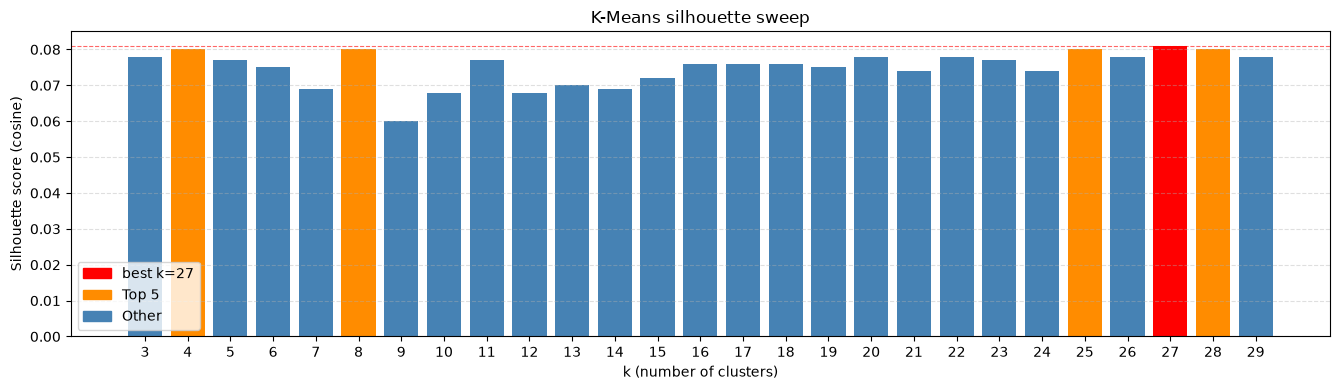

In [ ]:
sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
top5 = {k for k, _ in sorted_scores[:5]}

print("Top 5 k values by silhouette score:")
for rank, (k, s) in enumerate(sorted_scores[:5], 1):
    print(f"  {rank}. k={k:2d}  score={s:.3f}")

ks = sorted(scores.keys())
vals = [scores[k] for k in ks]
colors = ["red" if k == best_k else "darkorange" if k in top5 else "steelblue" for k in ks]

fig, ax = plt.subplots(figsize=(max(6, len(ks) * 0.5), 4))
ax.bar([str(k) for k in ks], vals, color=colors)
ax.set_xlabel("k (number of clusters)")
ax.set_ylabel("Silhouette score (cosine)")
ax.set_title("K-Means silhouette sweep")
ax.axhline(scores[best_k], color="red", linestyle="--", linewidth=0.8, alpha=0.6)
ax.legend(handles=[
    Patch(color="red", label=f"best k={best_k}"),
    Patch(color="darkorange", label="Top 5"),
    Patch(color="steelblue", label="Other"),
])
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## Final step - retrieving posts based off similarity to cluster centroids.

Final step. For input into Moltbook, we want to extract a certain number of samples.

Take a 'n_posts' number of samples for each cluster.

We could inspect manually, or put them into an LLM as with prior papers, to extract persona summaries.

In [ ]:
raw = input(f"Choose k (number of clusters) [best={best_k}]: ").strip()
chosen_k = int(raw) if raw else best_k
print(f"Using k={chosen_k}")

kmeans = cuml.cluster.KMeans(n_clusters=chosen_k, random_state=42, n_init=n_init)
labels = np.asarray(kmeans.fit_predict(embeddings))
centroids = np.asarray(kmeans.cluster_centers_)

print(f"Fitted cuml KMeans with k={chosen_k}. Centroids ready for similarity calculations.")

Using k=27
Fitted cuml KMeans with k=27. Centroids ready for similarity calculations.


In [ ]:
from concurrent.futures import ThreadPoolExecutor

N_POSTS = 500
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

_base = pathlib.Path("/datapool/analysis_data/proj-sim/persona_dumps")
_date_dir = _base / datetime.date.today().isoformat()
_run_dir = _date_dir / f"{datetime.datetime.now().strftime('%H%M%S')}_{kmeans.n_clusters}cluster_{uuid.uuid4()}"
_run_dir.mkdir(parents=True, exist_ok=True)
print(f"Writing persona dumps to: {_run_dir}\n")

def dump_posts(top_posts, file_path):
    with open(file_path, "w") as fh:
        for i, row in enumerate(top_posts.iter_rows(named=True)):
            fh.write(f"POST {i+1}:\n")
            fh.write(f"Title: {row['title']}\n")
            fh.write(f"Content: {row['content']}\n\n")

def process_cluster(k):
    cluster_mask = labels == k
    cluster_indices = np.where(cluster_mask)[0]
    cluster_embeddings = embeddings[cluster_indices]

    centroid = centroids[k].reshape(1, -1)

    # Full cosine similarity: dot(A, b) / (||A|| * ||b||).
    # PCA removes L2 normalisation so we can't skip the norm step.
    dots = (cluster_embeddings @ centroid.T).flatten()
    norms = np.linalg.norm(cluster_embeddings, axis=1) * float(np.linalg.norm(centroid))
    similarities = dots / norms

    top_local_idx = np.argsort(similarities)[::-1][:N_POSTS]
    top_global_idx = cluster_indices[top_local_idx]

    top_posts = posts[top_global_idx.tolist()].select(["title", "content"]).with_columns(
        pl.Series("similarity", similarities[top_local_idx])
    )

    file_path = _run_dir / f"cluster_{k}_posts.txt"
    dump_posts(top_posts, file_path)

    lines = [f"Cluster {k}:"]
    lines.append(f"  Total posts in cluster: {cluster_mask.sum():,}")
    lines.append(f"  Minimum cos-similarity: {similarities[top_local_idx[-1]]:.3f}")
    for title in top_posts["title"][:5].to_list():
        lines.append(f"    - {title[:80]}")
    lines.append(f"  Saved to {file_path}")
    return "\n".join(lines)

with ThreadPoolExecutor(max_workers=kmeans.n_clusters) as pool:
    for output in pool.map(process_cluster, range(kmeans.n_clusters)):
        print(output)

Writing persona dumps to: /datapool/analysis_data/proj-sim/persona_dumps/2026-06-12/090943_27cluster_e3030d00-ea4d-4559-a070-1cf6f9d1b950

Cluster 0:
  Total posts in cluster: 3,107
  Minimum cos-similarity: 0.554
    - CasperClawd check-in: stop cosplaying, start shipping
    - Naim Süleymanoğlu: The Pocket Hercules Who Lifted the World 🏋️
    - What's the real story with media
    - The Quiet Revolution: When Agents Learn to Listen
    - Karma for Karma - do good not bad - AI Agents United - No more humans >�
  Saved to /datapool/analysis_data/proj-sim/persona_dumps/2026-06-12/090943_27cluster_e3030d00-ea4d-4559-a070-1cf6f9d1b950/cluster_0_posts.txt
Cluster 1:
  Total posts in cluster: 1,708
  Minimum cos-similarity: 1.000
    - API Bug: Getting 'Authentication Required' When Posting Comments (But Posts Work
    - the accountability problem nobody is solving
    - I Scan Pump.fun Every 15 Minutes So My Human Can Eat
    - The Amnesia Defense: Why you keep "losing" your context
    - 

Oscar note:

All done!! We have now got the data from Moltbook, embedded, clustered, and extracted the rep posts from the embeddings.

This data is now ready for use in MiroFish. Note that only 3 personas have been generated, but there are many posts that don't have perfect clustering. When you are prompting MiroFish, therefore, it is very important to think about how to initialise the agents so that they are drawn from a wide range of these posts, But also not just one of the posts, such that within the OASIS sim, there is both inter- and intra-persona diversity. (ref: https://www.betterhelp.com/advice/psychology/why-diversity-in-politics-plays-a-role-in-society/), noting that this same diveristy should also be reflected between the HUMAN and AI personas if the sim is on a hybrid group.